# MA Transmuting LFR model

#### From Bin Liu et al., "Minor actinide transmutation in the lead-cooled fast reactor", 2020

In [1]:
%matplotlib inline
import openmc
import math

import os 
#os.environ['OPENMC_CROSS_SECTIONS']='openmc_venv/root/endf-b-vii.1/'
os.environ['OPENMC_CROSS_SECTIONS']='/openmc_data/endfb-viii.1-hdf5/cross_sections.xml'
print('done')


done


## General params

In [2]:
T_fuel = 823
# Sobolev: 823 K
T_cool = 713 
# Sobolev: (673 + 753) / 2 = 713 K

## Materials
Using actual materials compositions from article

### Isotopes

In [3]:

cu63 = openmc.Material(name='Cu63')
cu63.set_density('g/cm3', 8.83)
cu63.add_nuclide('Cu63', 1.0) #Density dervied from wiki

Al2O3 = openmc.Material(name='Al2O3')
Al2O3.set_density('g/cm3', 3.97) #Density dervied from wiki
Al2O3.add_element('O', 3.0)
Al2O3.add_element('Al', 2.0)


########### NEW ELEMENTS: ##########
####################################

Pb = openmc.Material(name='Pb')
Pb.add_element('Pb', 1.0)
Pb.set_density('g/cm3', 11.34)

UO2 = openmc.Material(name='UO2')
UO2.add_element('U', 1.0)
UO2.add_element('O', 2.0)
UO2.set_density('g/cm3',10.97)


########## To Boron-Carbide: #########
######################################
B_enriched = openmc.Material(name='B_enriched')
B_enriched.add_nuclide('B10', 0.92)
B_enriched.add_nuclide('B11', 0.08)


C_nat = openmc.Material(name='C_nat')
C_nat.add_nuclide('C12', 1.0)



########## Uranium and Plutonium Oxides: ########
#################################################

# Blanket UO2 (0.72% 235U, 99.28% 238U)
blanket_uo2 = openmc.Material(name='Blanket UO2')
blanket_uo2.set_density('g/cm3', 10.4)

blanket_uo2.add_nuclide('U235', 0.0072, 'ao')
blanket_uo2.add_nuclide('U238', 0.9928, 'ao')
blanket_uo2.add_element('O', 2.0, 'ao')   # stoichiometric UO2


# UO2 MOX
mox_uo2 = openmc.Material(name='MOX UO2')
mox_uo2.set_density('g/cm3', 10.4)

mox_uo2.add_nuclide('U234', 0.00003, 'wo')
mox_uo2.add_nuclide('U235', 0.00404, 'wo')   # Enrichment should be changed!!!!!!!!!!!!
mox_uo2.add_nuclide('U236', 0.00010, 'wo')
mox_uo2.add_nuclide('U238', 0.99583, 'wo')
mox_uo2.add_element('O', 2.0, 'ao')


# PuO2 vector 
puo2 = openmc.Material(name='PuO2')
puo2.set_density('g/cm3', 11.5)

puo2.add_nuclide('Pu238', 0.02332, 'wo')
puo2.add_nuclide('Pu239', 0.56873, 'wo')
puo2.add_nuclide('Pu240', 0.26997, 'wo')
puo2.add_nuclide('Pu241', 0.06105, 'wo')
puo2.add_nuclide('Pu242', 0.07693, 'wo')
puo2.add_element('O', 2.0, 'ao')


############### MA mixes:

Np237 = openmc.Material(name='Np237')
Np237.add_nuclide('Np237', 1.0)

Am241 = openmc.Material(name='Am241')
Am241.add_nuclide('Am241', 1.0)

Am243 = openmc.Material(name='Am243')
Am243.add_nuclide('Am243', 1.0)

Cm244 = openmc.Material(name='Cm244')
Cm244.add_nuclide('Cm244', 1.0)

Cm245 = openmc.Material(name='Cm245')
Cm245.add_nuclide('Cm245', 1.0)

######### Til T91: ###########
##############################

# Carbon
C = openmc.Material(name='C')
C.set_density('g/cm3', 2.266)
C.add_nuclide('C12', 1)

# Nitrogen
N = openmc.Material(name='N')
N.set_density('g/cm3', 1.165e-3)  # gas at STP
N.add_element('N', 1)

# Aluminum
Al = openmc.Material(name='Al')
Al.set_density('g/cm3', 2.70)
Al.add_element('Al', 1)

# Silicon
Si = openmc.Material(name='Si')
Si.set_density('g/cm3', 2.33)
Si.add_element('Si', 1)

# Phosphorus
P = openmc.Material(name='P')
P.set_density('g/cm3', 1.82)
P.add_element('P', 1)

# Sulfur
S = openmc.Material(name='S')
S.set_density('g/cm3', 2.07)
S.add_element('S', 1)

# Vanadium
V = openmc.Material(name='V')
V.set_density('g/cm3', 6.11)
V.add_element('V', 1)

# Chromium
Cr = openmc.Material(name='Cr')
Cr.set_density('g/cm3', 7.19)
Cr.add_element('Cr', 1)

# Manganese
Mn = openmc.Material(name='Mn')
Mn.set_density('g/cm3', 7.21)
Mn.add_element('Mn', 1)

# Iron
Fe = openmc.Material(name='Fe')
Fe.set_density('g/cm3', 7.87)
Fe.add_element('Fe', 1)

# Nickel
Ni = openmc.Material(name='Ni')
Ni.set_density('g/cm3', 8.90)
Ni.add_element('Ni', 1)

# Copper
Cu = openmc.Material(name='Cu')
Cu.set_density('g/cm3', 8.96)
Cu.add_element('Cu', 1)

# Niobium
Nb = openmc.Material(name='Nb')
Nb.set_density('g/cm3', 8.57)
Nb.add_element('Nb', 1)

# Molybdenum
Mo = openmc.Material(name='Mo')
Mo.set_density('g/cm3', 10.28)
Mo.add_element('Mo', 1)

# Helium
He = openmc.Material(name='He')
He.set_density('g/cm3', 0.0001785)
He.add_element('He', 1)


### Fuel and MA mixtures

In [4]:
# Material mixtures

###### New Mixtures############
########################

#Minor Actinide mix:
MA_mix = openmc.Material.mix_materials(
    [Np237, Am241, Am243, Cm244, Cm245],
    [0.5618, 0.264, 0.12, 0.0514, 0.0028],
    percent_type='wo'
)
MA_mix.name = "Minor Actinide Mixture"
MA_mix.depletable = True
MA_mix.set_density('g/cm3', 11.0)   # example density; adjust if needed

####
T91 = openmc.Material.mix_materials(
    [C, N, Al, Si, P, S, V, Cr, Mn, Fe, Ni, Cu, Nb, Mo],
    [0.001, 0.00048, 0.00022, 0.0028, 0.00009, 0.00003, 0.00216, 0.0837, 0.0045, 0.89146, 0.0021, 0.0017, 0.00076, 0.009], 'wo')
T91.depletable = True


B4C = openmc.Material.mix_materials(
    [B_enriched, C_nat],
    [0.8, 0.2],
    percent_type='ao'   # atomic fractions
)
B4C.name = "B4C (92% B10)"
B4C.depletable = True
B4C.set_density('g/cm3', 2.52)


Lead = openmc.Material.mix_materials(
    [Pb],
    [1.0],
    percent_type='ao'   # atomic fractions
)
Lead.depletable = True
Lead.name = "Lead (coolant)"

####  FUEL MIXES:

# Internal area
fuel_inner = openmc.Material.mix_materials(
    [mox_uo2, puo2],
    [0.862, 0.138],
    percent_type='wo'
)
fuel_inner.name = 'Fuel inner'
fuel_inner.depletable = True
fuel_inner.set_density('g/cm3', 10.5)   # example density


# Intermediate area
fuel_mid = openmc.Material.mix_materials(
    [mox_uo2, puo2],
    [0.835, 0.165],
    percent_type='wo'
)
fuel_mid.name = 'Fuel intermediate'
fuel_mid.depletable = True
fuel_mid.set_density('g/cm3', 10.5)


# Outmost area
fuel_outer = openmc.Material.mix_materials(
    [mox_uo2, puo2],
    [0.788, 0.212],
    percent_type='wo'
)
fuel_outer.name = 'Fuel outer'
fuel_outer.depletable = True
fuel_outer.set_density('g/cm3', 10.5)

### Setting % of MAs

In [5]:
######## INSERT HERE: ###########
percent = 0

percent = percent*1e-2
#print(MA_mix)

U_in_fuel = 0.862*(1-percent)
Pu_in_fuel = 0.138*(1-percent)
print("U_in_fuel", U_in_fuel)
print("Pu_in_fuel", Pu_in_fuel)
print("MA_in_fuel", percent)

U_mid_fuel = 0.835*(1-percent)
Pu_mid_fuel = 0.165*(1-percent)
print("U_mid_fuel", U_mid_fuel)
print("Pu_mid_fuel", Pu_mid_fuel)
print("MA_mid_fuel", percent)

U_out_fuel = 0.788*(1-percent)
Pu_out_fuel = 0.212*(1-percent)
print("U_out_fuel", U_out_fuel)
print("Pu_out_fuel", Pu_out_fuel)
print("MA_out_fuel", percent)

#Minor Actinide mix:
MA_mix = openmc.Material.mix_materials(
    [Np237, Am241, Am243, Cm244, Cm245],
    [0.5618, 0.264, 0.12, 0.0514, 0.0028],
    percent_type='wo'
    ,temperature = T_fuel

)
MA_mix.name = "Minor Actinide Mixture"
MA_mix.set_density('g/cm3', 11.0)   # example density; adjust if needed


# internal fuel material
mat_in_fuel = openmc.Material.mix_materials(
    [mox_uo2, puo2, MA_mix],
    [U_in_fuel, Pu_in_fuel, percent],
    percent_type='wo',
    name = 'internal fuel'
    ,temperature = T_fuel

)
mat_in_fuel.depletable = True

# middle (intermediate) fuel material
mat_mid_fuel = openmc.Material.mix_materials(
    [mox_uo2, puo2, MA_mix],
    [U_mid_fuel, Pu_mid_fuel, percent],
    percent_type='wo',
    name = 'middle fuel'
    ,temperature = T_fuel

)
mat_mid_fuel.depletable = True

# outmost fuel material
mat_out_fuel = openmc.Material.mix_materials(
    [mox_uo2, puo2, MA_mix],
    [U_out_fuel, Pu_out_fuel , percent],
    percent_type='wo',
    name = 'outmost fuel',
    temperature = T_fuel
)
mat_out_fuel.depletable = True

U_in_fuel 0.862
Pu_in_fuel 0.138
MA_in_fuel 0.0
U_mid_fuel 0.835
Pu_mid_fuel 0.165
MA_mid_fuel 0.0
U_out_fuel 0.788
Pu_out_fuel 0.212
MA_out_fuel 0.0


### Non-fuel materials

In [6]:
# clad material
mat_clad = openmc.Material.mix_materials(
    [C, N, Al, Si, P, S, V, Cr, Mn, Fe, Ni, Cu, Nb, Mo],
    [0.001, 0.00048, 0.00022, 0.0028, 0.00009, 0.00003, 0.00216, 0.0837, 0.0045, 0.89146, 0.0021, 0.0017, 0.00076, 0.009], 'wo'
        ,temperature = T_fuel
    )
mat_clad.depletable = True

# helium gap material
mat_gap = openmc.Material.mix_materials(
    [He], [1], 'wo',
    name = 'helium gap'
    ,temperature = T_fuel

)
mat_gap.depletable = True

# blanket material
mat_blan = openmc.Material.mix_materials(
    [mox_uo2], [1], 'wo',
    name = 'blanket'
    ,temperature = T_fuel

)
mat_blan.depletable = True

# control rod material
mat_cont = openmc.Material.mix_materials(
    [B_enriched, C_nat],
    [0.8, 0.2],
    percent_type='ao'   # atomic fractions
    ,temperature = T_fuel
)
mat_cont.depletable = True
B4C.name = "B4C (92% B10)"
B4C.set_density('g/cm3', 2.52)

# coolant (lead) material

mat_cool = openmc.Material.mix_materials(
    [Pb],
    [1.0],
    percent_type='ao'   # atomic fractions
    ,temperature = T_cool

)
mat_cool.depletable = True

Wait with saving the materials file till geometry is defined


In [7]:
# Instantiate a Materials collection and export to xml
materials_file = openmc.Materials([
    mat_in_fuel, 
    mat_mid_fuel,
    mat_out_fuel,
    mat_clad,
    mat_gap,
    mat_blan,
    mat_cont,
    mat_cool])

#materials_file.export_to_xml()


## Geometry

### Regions

In [8]:
# Size parameters (NB: OpenMC uses cm)
diam_fuel_pellet = 9.1e-1 #diameter of fuel pellet
thick_clad = 0.4e-1 #thickness of clad
out_diam_clad = 10.4e-1 #outer diameter of clad
in_diam_clad = out_diam_clad - thick_clad*2 #inner diameter of clad
height_core = 110 #active core height


# Surfaces
surf_fuel_or = openmc.ZCylinder(r=diam_fuel_pellet/2, name='fuel pellet') 
surf_clad_ir = openmc.ZCylinder(r=in_diam_clad/2, name='clad inner radius')
surf_clad_or = openmc.ZCylinder(r=out_diam_clad/2, name='clad outer radius')

surf_top = openmc.ZPlane(z0=height_core/2, boundary_type='vacuum', name='top')
surf_bot = openmc.ZPlane(z0=-height_core/2, boundary_type='vacuum', name='bottom')

# Regions
reg_fuel = -surf_top & +surf_bot & -surf_fuel_or 
reg_gap = -surf_top & +surf_bot & +surf_fuel_or & -surf_clad_ir
reg_clad = -surf_top & +surf_bot & +surf_clad_ir & -surf_clad_or
reg_cool =  -surf_top & +surf_bot & + surf_clad_or

#control rod geometry not specified in B. Liu: assumed not cladding
reg_cont = -surf_top & +surf_bot & -surf_clad_or 

### Primitive cells

In [9]:
# Fuel
cell_in_fuel = openmc.Cell(fill=mat_in_fuel, region=reg_fuel, name='fuel, internal')
cell_mid_fuel = openmc.Cell(fill=mat_mid_fuel, region=reg_fuel, name='fuel, middle')
cell_out_fuel = openmc.Cell(fill=mat_out_fuel, region=reg_fuel, name='fuel, outmost')



#(Defining multiple similar cells, in order for universes to avoid using same cells)
# Gap
cell_in_gap = openmc.Cell(fill=mat_gap, region=reg_gap, name='gap, internal')
cell_mid_gap = openmc.Cell(fill=mat_gap, region=reg_gap, name='gap, middle')
cell_out_gap = openmc.Cell(fill=mat_gap, region=reg_gap, name='gap, outmost')

# Clad
cell_in_clad = openmc.Cell(fill=mat_clad, region=reg_clad, name='clad, internal')
cell_mid_clad = openmc.Cell(fill=mat_clad, region=reg_clad, name='clad, middle')
cell_out_clad = openmc.Cell(fill=mat_clad, region=reg_clad, name='clad, outmost')

# Coolant
cell_in_cool = openmc.Cell(fill=mat_cool, region=reg_cool, name='coolant, internal')
cell_mid_cool = openmc.Cell(fill=mat_cool, region=reg_cool, name='coolant, middle')
cell_out_cool = openmc.Cell(fill=mat_cool, region=reg_cool, name='coolant, outmost')

# Coolant, but as filling for empty space in the core 
cell_empty_cool = openmc.Cell(fill=mat_cool, name='coolant, empty space in lattice') 

# Blanket
cell_blan = openmc.Cell(fill=mat_blan, region=reg_fuel, name='blanket')
cell_gap_blan = openmc.Cell(fill=mat_gap, region=reg_gap, name='gap in blanket ass.')
cell_clad_blan = openmc.Cell(fill=mat_clad, region=reg_clad, name='clad in blanket ass.')
cell_cool_blan = openmc.Cell(fill=mat_cool, region=reg_cool, name='coolant in blanket ass.')

# Control rod 
#control assemblies not specified in B. Liu: 
#assumed that not all rods in control assembly are control material, but that some are fuel material
#--> need for defining more similar cells to avoid dubilcation in universe creation
cell_in_cont = openmc.Cell(fill=mat_cont, region=reg_cont, name='control rod, internal')
cell_out_cont = openmc.Cell(fill=mat_cont, region=reg_cont, name='control rod, outmost')

cell_in_fuel_cont = openmc.Cell(fill=mat_in_fuel, region=reg_fuel, name='fuel in cont. ass., internal')
cell_out_fuel_cont = openmc.Cell(fill=mat_out_fuel, region=reg_fuel, name='fuel in cont. ass., outmost')

cell_in_gap_cont = openmc.Cell(fill=mat_gap, region=reg_gap, name='gap in cont. ass., internal')
cell_out_gap_cont = openmc.Cell(fill=mat_gap, region=reg_gap, name='gap in cont. ass., outmost')

cell_in_clad_cont = openmc.Cell(fill=mat_clad, region=reg_clad, name='clad in cont. ass., internal')
cell_out_clad_cont = openmc.Cell(fill=mat_clad, region=reg_clad, name='clad in cont. ass., outmost')

cell_in_cool_cont = openmc.Cell(fill=mat_cool, region=reg_cool, name='coolant in cont. ass., internal')
cell_out_cool_cont = openmc.Cell(fill=mat_cool, region=reg_cool, name='coolant in cont. ass., outmost')

# Assembly Cladding:
cell_in_as_clad = openmc.Cell(fill=mat_clad, region=reg_clad, name='clad, internal')
cell_mid_as_clad = openmc.Cell(fill=mat_clad, region=reg_clad, name='clad, middle')
cell_out_as_clad = openmc.Cell(fill=mat_clad, region=reg_clad, name='clad, outmost')
# 

### Primitive universes

In [10]:
# For fuel assemblies (internal, middle, outmost)
uni_in_fuel = openmc.Universe(
    cells=(cell_in_fuel, cell_in_gap, cell_in_clad, cell_in_cool),
    name='fuel assembly, internal'
    )
uni_mid_fuel = openmc.Universe(
    cells=(cell_mid_fuel, cell_mid_gap, cell_mid_clad, cell_mid_cool),
    name='fuel assembly, middle'
    )
uni_out_fuel = openmc.Universe(
    cells=(cell_out_fuel, cell_out_gap, cell_out_clad, cell_out_cool),
    name='fuel assembly, outmost'
    )

# For blanket assemblies
uni_blan = openmc.Universe(
    cells=(cell_blan, cell_gap_blan, cell_clad_blan, cell_cool_blan),
    name='blanket assembly'
    )

# For coolant in empty space in core
uni_empty_cool = openmc.Universe(cells=(cell_empty_cool,), name='coolant, empty space in lattice')

# For control assemblies
uni_in_cont = openmc.Universe(
    cells=(cell_in_cont, cell_in_fuel_cont, cell_in_gap_cont, cell_in_clad_cont, cell_in_cool_cont),
    name='control assembly, internal'
    )
uni_out_cont = openmc.Universe(
    cells=(cell_out_cont, cell_out_fuel_cont, cell_out_gap_cont, cell_out_clad_cont, cell_out_cool_cont),
    name='control assembly, outmost'
    )

In [11]:
# Plotting colors for cells

#...

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

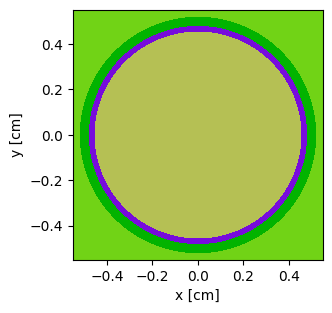

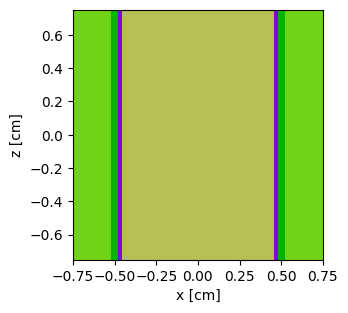

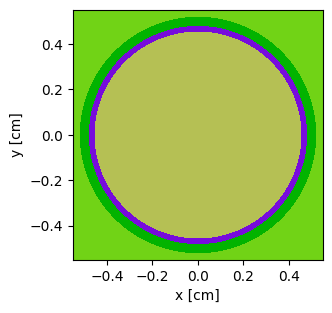

In [12]:
# Plotting
uni_in_fuel.plot(origin=(0.,0.,0.), pixels=(250, 250), width=(1.1,1.1), color_by='cell')
uni_in_fuel.plot(origin=(0.,0.,0.), pixels=(250, 250), width=(1.5,1.5), color_by='cell', basis='xz')
uni_blan.plot(origin=(0.,0.,0.), pixels=(250, 250), width=(1.1,1.1), color_by='cell')

### Lattice for internal fuel assemblies

In [13]:
# Size parameters for all lattices
pitch_fuel_rod = 13.6e-1 #fuel rod pitch

#Edge length of inner hexagonal for fuel assembly casing, (inner hexagonal, since casing has a thickness) 
edge_fuel_ass_in = 5.5*pitch_fuel_rod # factor before 'pitch_fuel_rod' is chosen at will...
print('Edge length of inner hexagonal: ', edge_fuel_ass_in)

#Thickness of outer hexagonal casing 
thick_ass_casing = 0.4

#Edge length of outer hexagonal casing 
#(NB: geometrix consideration needed, as dist. betw. same corner for inner and outer hex. not equal given thickness of casing)

edge_fuel_ass_out = edge_fuel_ass_in + 2/math.sqrt(3)*thick_ass_casing 
print('Edge length of outer hexagonal: ', edge_fuel_ass_out)


Edge length of inner hexagonal:  7.48
Edge length of outer hexagonal:  7.941880215351701


In [14]:
# Defining lattice parameters
lat_in_fuel = openmc.HexLattice(name='internal fuel assembly')
lat_in_fuel.center = (0.,0.)
lat_in_fuel.pitch = (pitch_fuel_rod,)
lat_in_fuel.orientation = 'x'
lat_in_fuel.outer = uni_empty_cool

In [15]:
#Show layout of assemblies and indices
print(lat_in_fuel.show_indices(num_rings=6, orientation = 'x'))

                              (0,20)      (0,21)      (0,22)      (0,23)      (0,24)      (0,25)

                        (0,19)      (1,16)      (1,17)      (1,18)      (1,19)      (1,20)      (0,26)

                  (0,18)      (1,15)      (2,12)      (2,13)      (2,14)      (2,15)      (1,21)      (0,27)

            (0,17)      (1,14)      (2,11)      (3, 8)      (3, 9)      (3,10)      (2,16)      (1,22)      (0,28)

      (0,16)      (1,13)      (2,10)      (3, 7)      (4, 4)      (4, 5)      (3,11)      (2,17)      (1,23)      (0,29)

(0,15)      (1,12)      (2, 9)      (3, 6)      (4, 3)      (5, 0)      (4, 0)      (3, 0)      (2, 0)      (1, 0)      (0, 0)

      (0,14)      (1,11)      (2, 8)      (3, 5)      (4, 2)      (4, 1)      (3, 1)      (2, 1)      (1, 1)      (0, 1)

            (0,13)      (1,10)      (2, 7)      (3, 4)      (3, 3)      (3, 2)      (2, 2)      (1, 2)      (0, 2)

                  (0,12)      (1, 9)      (2, 6)      (2, 5)      (2, 4)      (2, 3)

In [16]:
# Creating 6 rings
infuel1 = [uni_in_fuel] * (6-1)*6 #=30
infuel2 = [uni_in_fuel] * (6-2)*6
infuel3 = [uni_in_fuel] * (6-3)*6 #...
infuel4 = [uni_in_fuel] * (6-4)*6 #=12
infuel5 = [uni_in_fuel] * (6-5)*6 #=6
infuel6 = [uni_in_fuel] * 1
lat_in_fuel.universes = [infuel1, infuel2, infuel3, infuel4, infuel5, infuel6]
 
# Create prisms that will define lattice and assembly cladding 
surf_inlat_in_fuel = openmc.model.HexagonalPrism(edge_length=edge_fuel_ass_in, orientation='x', boundary_type = 'reflective') #'inlat' = inner lattice
surf_outlat_in_fuel = openmc.model.HexagonalPrism(edge_length=edge_fuel_ass_out, orientation='x', boundary_type = 'reflective') #'outlat' = outer lattice

edge_fuel_ass_out_BC = edge_fuel_ass_out + 0.5
surf_outlat_BC_in_fuel = openmc.model.HexagonalPrism(edge_length=edge_fuel_ass_out_BC, orientation='x', boundary_type = 'reflective') #'outlat' = outer lattice

# Region
reg_main_lat_in_fuel = -surf_top & + surf_bot & -surf_inlat_in_fuel #inside inner hexagonal (for fuel rod lattice)
reg_clad_lat_in_fuel = -surf_top & + surf_bot & +surf_inlat_in_fuel & -surf_outlat_in_fuel #between two hex. surf. (for cladding)


reg_out_lat_in_fuel_BC = -surf_top & + surf_bot & +surf_outlat_BC_in_fuel # BOUNRDARY COMDIMTIONS
reg_out_lat_in_fuel = -surf_top & + surf_bot & +surf_outlat_in_fuel #outside outer hexagonal (for coolant)




#Fill a cell with the lattice. This cell is filled with the lattice and contained within the prism
cell_main_lat_in_fuel = openmc.Cell(fill=lat_in_fuel, region=reg_main_lat_in_fuel)
#cladding:
cell_clad_lat_in_fuel = openmc.Cell(fill=mat_clad, region=reg_clad_lat_in_fuel)

cell_out_lat_in_fuel_BC = openmc.Cell(fill=mat_clad, region=reg_out_lat_in_fuel_BC)

#Fill a cell with a material that will surround the prism assembly
cell_out_lat_in_fuel = openmc.Cell(fill=mat_cool, region=reg_out_lat_in_fuel)


# Universe containing the cells
uni_main_in_fuel = openmc.Universe(
    cells=[cell_main_lat_in_fuel, cell_clad_lat_in_fuel, cell_out_lat_in_fuel,cell_out_lat_in_fuel_BC], 
    name='fuel assembly lattice, internal')

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

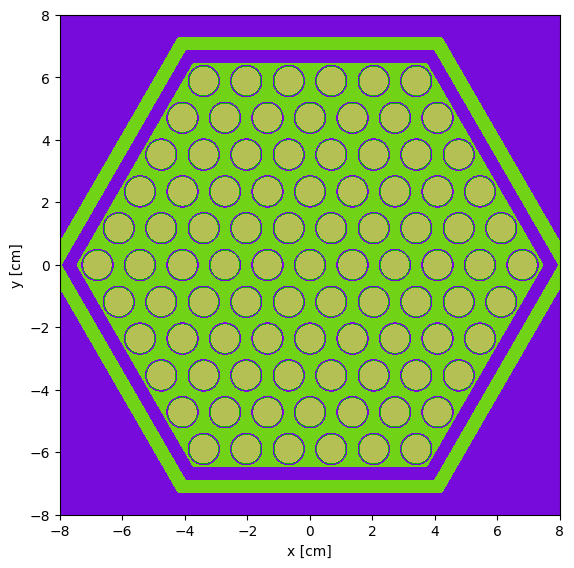

In [17]:
# Plotting 
uni_main_in_fuel.plot(origin=(0.,0.,0.), pixels=(500, 500), width=(16,16), color_by='material')

### Lattice for middle fuel assemblies

In [18]:
# Defining lattice parameters
lat_mid_fuel = openmc.HexLattice(name='middle fuel assembly')
lat_mid_fuel.center = (0.,0.)
lat_mid_fuel.pitch = (pitch_fuel_rod,)
lat_mid_fuel.orientation = 'x'
lat_mid_fuel.outer = uni_empty_cool

In [19]:
# Creating 6 rings
midfuel1 = [uni_mid_fuel] * (6-1)*6 #=30
midfuel2 = [uni_mid_fuel] * (6-2)*6
midfuel3 = [uni_mid_fuel] * (6-3)*6 #...
midfuel4 = [uni_mid_fuel] * (6-4)*6 #=12
midfuel5 = [uni_mid_fuel] * (6-5)*6 #=6
midfuel6 = [uni_mid_fuel] * 1
lat_mid_fuel.universes = [midfuel1, midfuel2, midfuel3, midfuel4, midfuel5, midfuel6]

# Create prisms that will define lattice and assembly cladding 
surf_inlat_mid_fuel = openmc.model.HexagonalPrism(edge_length=edge_fuel_ass_in, orientation='x') #'inlat' = inner lattice
surf_outlat_mid_fuel = openmc.model.HexagonalPrism(edge_length=edge_fuel_ass_out, orientation='x') #'outlat' = outer lattice

# Region
reg_main_lat_mid_fuel = -surf_top & + surf_bot & -surf_inlat_mid_fuel #inside inner hexagonal (for fuel rod lattice)
reg_clad_lat_mid_fuel = -surf_top & + surf_bot & +surf_inlat_mid_fuel & -surf_outlat_mid_fuel #between two hex. surf. (for cladding)
reg_out_lat_mid_fuel = -surf_top & + surf_bot & +surf_outlat_mid_fuel #outside outer hexagonal (for coolant)

#Fill a cell with the lattice. This cell is filled with the lattice and contained within the prism
cell_main_lat_mid_fuel = openmc.Cell(fill=lat_mid_fuel, region=reg_main_lat_mid_fuel)
#Cladding
cell_clad_lat_mid_fuel = openmc.Cell(fill=mat_clad, region=reg_clad_lat_mid_fuel)
#Fill a cell with a material that will surround the prism assembly
cell_out_lat_mid_fuel = openmc.Cell(fill=mat_cool, region=reg_out_lat_mid_fuel)

# Universe containing the cells
uni_main_mid_fuel = openmc.Universe(
    cells=[cell_main_lat_mid_fuel, cell_clad_lat_mid_fuel, cell_out_lat_mid_fuel], 
    name='fuel assembly lattice, middle')

### Lattice for outmost fuel assemblies

In [20]:
# Defining lattice parameters
lat_out_fuel = openmc.HexLattice(name='outmost fuel assembly')
lat_out_fuel.center = (0.,0.)
lat_out_fuel.pitch = (pitch_fuel_rod,)
lat_out_fuel.orientation = 'x'
lat_out_fuel.outer = uni_empty_cool

In [21]:
# Creating 6 rings
outfuel1 = [uni_out_fuel] * (6-1)*6 #=30
outfuel2 = [uni_out_fuel] * (6-2)*6
outfuel3 = [uni_out_fuel] * (6-3)*6 #...
outfuel4 = [uni_out_fuel] * (6-4)*6 #=12
outfuel5 = [uni_out_fuel] * (6-5)*6 #=6
outfuel6 = [uni_out_fuel] * 1
lat_out_fuel.universes = [outfuel1, outfuel2, outfuel3, outfuel4, outfuel5, outfuel6]

# Create prisms that will define lattice and assembly cladding 
surf_inlat_out_fuel = openmc.model.HexagonalPrism(edge_length=edge_fuel_ass_in, orientation='x') #'inlat' = inner lattice
surf_outlat_out_fuel = openmc.model.HexagonalPrism(edge_length=edge_fuel_ass_out, orientation='x') #'outlat' = outer lattice

# Region
reg_main_lat_out_fuel = -surf_top & + surf_bot & -surf_inlat_out_fuel #inside inner hexagonal (for fuel rod lattice)
reg_clad_lat_out_fuel = -surf_top & + surf_bot & +surf_inlat_out_fuel & -surf_outlat_out_fuel #between two hex. surf. (for cladding)
reg_out_lat_out_fuel = -surf_top & + surf_bot & +surf_outlat_out_fuel #outside outer hexagonal (for coolant)

#Fill a cell with the lattice. This cell is filled with the lattice and contained within the prism
cell_main_lat_out_fuel = openmc.Cell(fill=lat_out_fuel, region=reg_main_lat_out_fuel)
#Cladding
cell_clad_lat_out_fuel = openmc.Cell(fill=mat_clad, region=reg_clad_lat_out_fuel)
#Fill a cell with a material that will surround the prism assembly
cell_out_lat_out_fuel = openmc.Cell(fill=mat_cool, region=reg_out_lat_out_fuel)

# Universe containing the cells
uni_main_out_fuel = openmc.Universe(
    cells=[cell_main_lat_out_fuel, cell_clad_lat_out_fuel, cell_out_lat_out_fuel], 
    name='fuel assembly lattice, outmost')

### Lattice for control rod assemblies

Control rod assemblies will be modeled as coolant to begin with (see below)...

### Lattice for blanket assemblies

In [22]:
# Defining lattice parameters
lat_blan = openmc.HexLattice(name='blanket assembly')
lat_blan.center = (0.,0.)
lat_blan.pitch = (pitch_fuel_rod,)
lat_blan.orientation = 'x'
lat_blan.outer = uni_empty_cool

In [23]:
# Creating 6 rings
blan1 = [uni_blan] * (6-1)*6 #=30
blan2 = [uni_blan] * (6-2)*6
blan3 = [uni_blan] * (6-3)*6 #...
blan4 = [uni_blan] * (6-4)*6 #=12
blan5 = [uni_blan] * (6-5)*6 #=6
blan6 = [uni_blan] * 1
lat_blan.universes = [blan1, blan2, blan3, blan4, blan5, blan6]

# Create prisms that will define lattice and assembly cladding 
surf_inlat_blan = openmc.model.HexagonalPrism(edge_length=edge_fuel_ass_in, orientation='x') #'inlat' = inner lattice
surf_outlat_blan = openmc.model.HexagonalPrism(edge_length=edge_fuel_ass_out, orientation='x') #'outlat' = outer lattice

# Region
reg_main_lat_blan = -surf_top & + surf_bot & -surf_inlat_blan #inside inner hexagonal (for fuel rod lattice)
reg_clad_lat_blan = -surf_top & + surf_bot & +surf_inlat_blan & -surf_outlat_blan #between two hex. surf. (for cladding)
reg_out_lat_blan = -surf_top & + surf_bot & +surf_outlat_blan #outside outer hexagonal (for coolant)

#Fill a cell with the lattice. This cell is filled with the lattice and contained within the prism
cell_main_lat_blan = openmc.Cell(fill=lat_blan, region=reg_main_lat_blan)
#Cladding
cell_clad_lat_blan = openmc.Cell(fill=mat_clad, region=reg_clad_lat_blan)
#Fill a cell with a material that will surround the prism assembly
cell_out_lat_blan = openmc.Cell(fill=mat_cool, region=reg_out_lat_blan)

# Universe containing the cells
uni_main_blan = openmc.Universe(
    cells=[cell_main_lat_blan, cell_clad_lat_blan, cell_out_lat_blan], 
    name='fuel assembly lattice, blanket')

### Hexagonal coolant cell (instead of control rod assembly)

In [24]:
# Create prism that will contain coolant (unsure of dimensions!)
surf_inlat_cool = openmc.model.HexagonalPrism(edge_length=edge_fuel_ass_in, orientation='x') #'inlat' = inner lattice
#No casing, so only inner prism

# Region
reg_main_lat_cool = -surf_top & + surf_bot & -surf_inlat_cool
reg_out_lat_cool = -surf_top & + surf_bot & +surf_inlat_cool

#Fill the prism with the coolant. 
cell_main_lat_cool = openmc.Cell(fill=mat_cool, region=reg_main_lat_cool)
#Fill a cell with a material that will sourrind the prism
cell_out_lat_cool = openmc.Cell(fill=mat_cool, region=reg_out_lat_cool)

# Universe containing both
uni_main_cool = openmc.Universe(
    cells=[cell_main_lat_cool, cell_out_lat_cool], 
    name='coolant hexagonal (subs. control ass.)')

### Core lattice layout

In [25]:
# Size parameters for core

#clearance (gap) between assemblies (from Sobolev et all)
clearance_ass_neigh = 0.5
#from hexagon geometry and its consistent triangles' 'height', the thickness of clad casing, and the clearance
pitch_core = math.sqrt(3)*edge_fuel_ass_in + 2*thick_ass_casing + clearance_ass_neigh
print('Core pitch: ',pitch_core)

#equivalent diameter of core (from B. Liu)
diam_core = 300

Core pitch:  14.255740040615203


In [26]:
# Defining lattice parameters
lat_core = openmc.HexLattice(name='core')
lat_core.center = (0.,0.)
lat_core.pitch = (pitch_core,)
lat_core.orientation = 'y'
lat_core.outer = uni_empty_cool

In [27]:
# Create 11 rings

#Blanket assembly rings
c_blan1 = ([uni_main_cool]*2 + [uni_main_blan]*7 + [uni_main_cool]) *6 #NB: has 'holes'
c_blan2 = [uni_main_blan] * 9*6
#Outmost fuel (and control) assembly rings
c_out1 = [uni_main_out_fuel] * 8*6
c_out2 = ([uni_main_cool] + 6*[uni_main_out_fuel]) * 6 #NB: with control assemblies
#Middle fuel assembly rings
c_mid1 = [uni_main_mid_fuel] * 6*6
c_mid2 = [uni_main_mid_fuel] * 5*6
#Internal fuel (and control) assembly rings
c_in1 = (2*[uni_main_in_fuel] + [uni_main_cool] + [uni_main_in_fuel]) * 6 #NB with control assemblies
c_in2 = [uni_main_in_fuel] * 3*6
c_in3 = [uni_main_in_fuel] * 2*6
c_in4 = [uni_main_in_fuel] * 6
c_in5 = [uni_main_in_fuel] * 1

lat_core.universes = [
    c_in5
]

lat_core.universes = [
    c_in5
]

In [28]:
# Create cylinder that will contain core 
surf_core = openmc.ZCylinder(r=diam_core/2/15, name='core outer surface', boundary_type='vacuum')

# Region
reg_main_core = -surf_top & + surf_bot & -surf_core
reg_out_core = -surf_top & + surf_bot & +surf_core

#Fill a cell with the assembly-lattices. This cell is filled with the lattice and contained within the cylinder
cell_main_core = openmc.Cell(fill=lat_core, region=reg_main_core)

# Universe containing both
uni_main_core = openmc.Universe(
    cells=[cell_main_core], 
    name='core')

<Axes: xlabel='x [cm]', ylabel='z [cm]'>

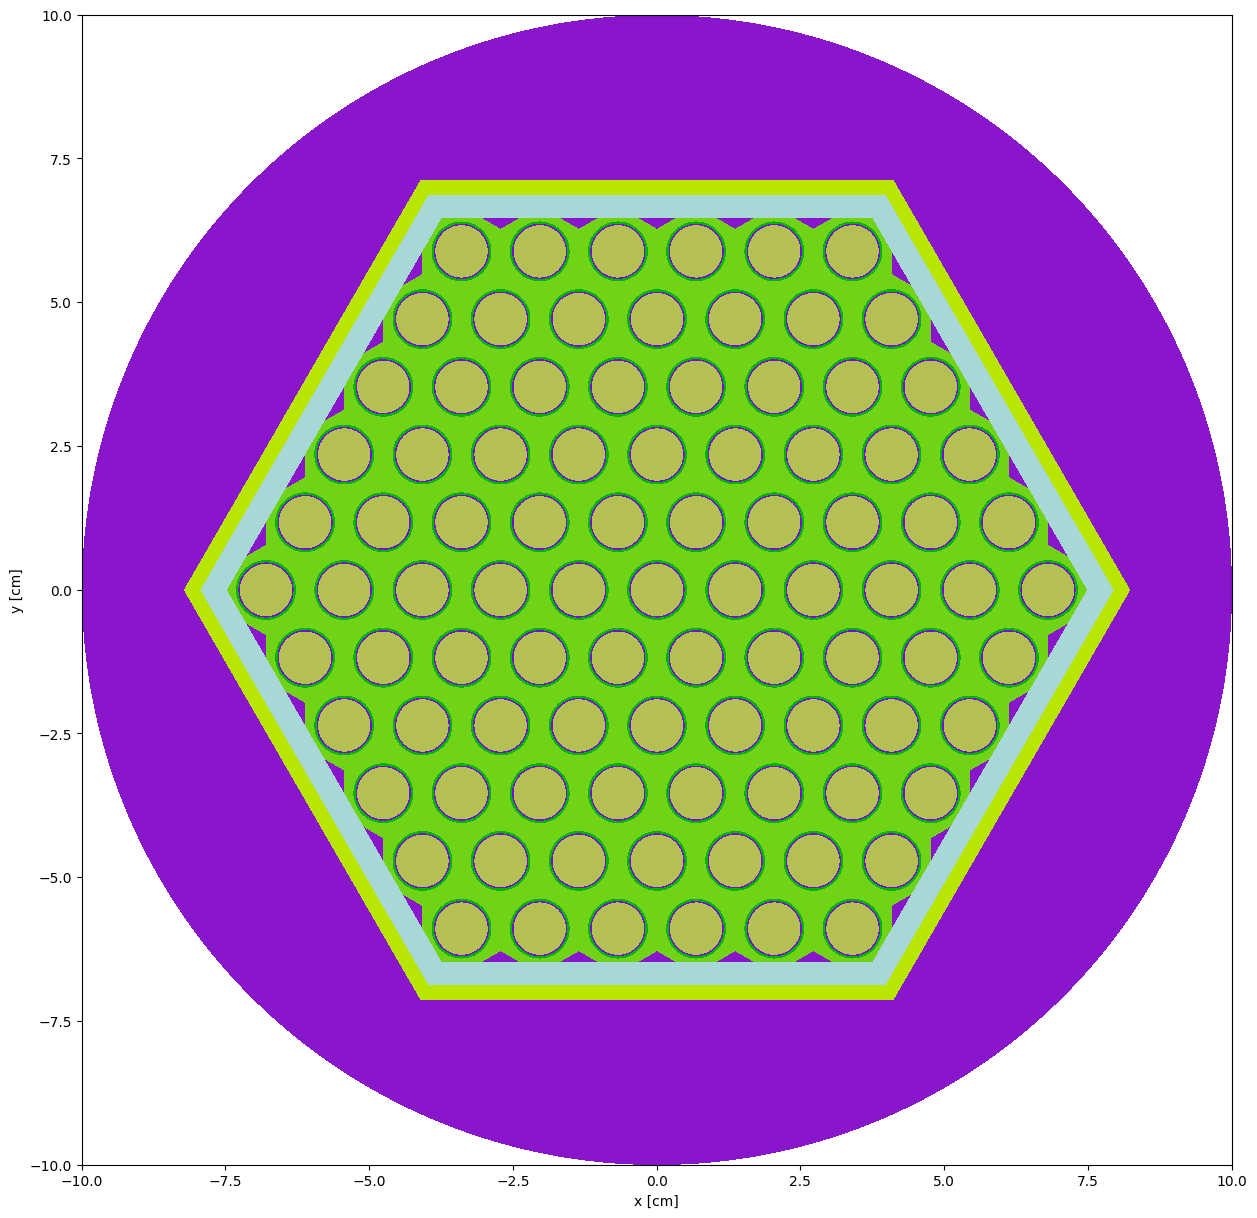

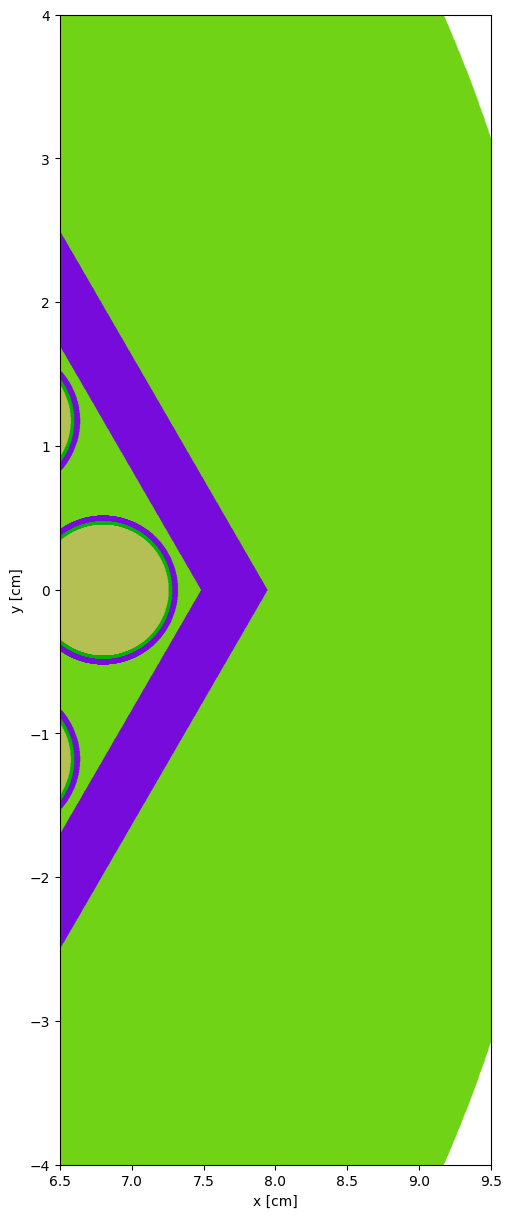

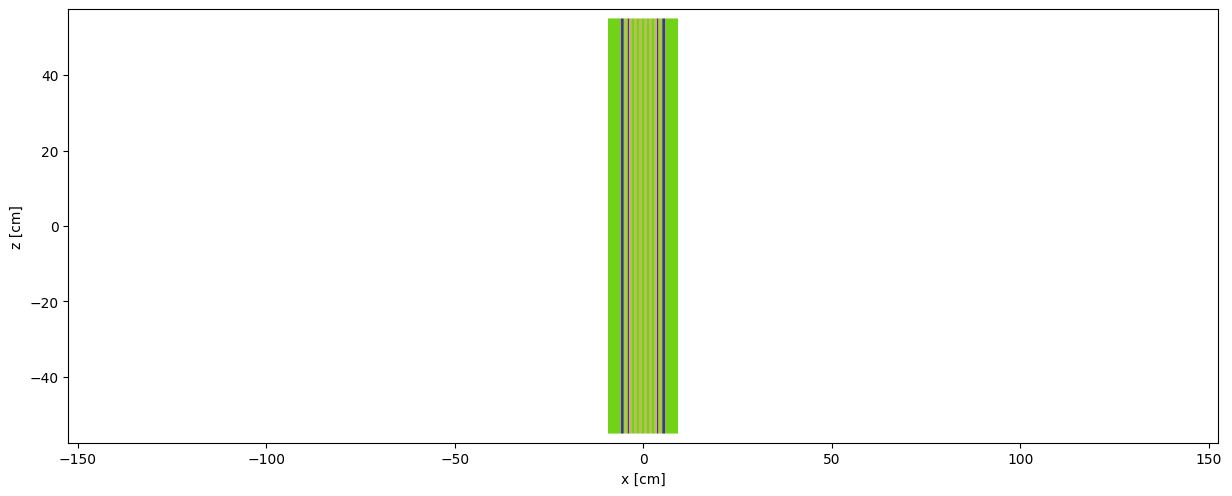

In [29]:
#Plotting
COLOR_BY_OPTION = 'material' #choose either 'material' or 'cell'
uni_main_core.plot(origin=(0.,0.,0.), pixels=(1150,1150), width=(20,20), color_by='cell')
uni_main_core.plot(origin=(8.,0.,0.), pixels=(1150,1150), width=(3.,8.), color_by=COLOR_BY_OPTION) #zoom on gap betw. assemblies
uni_main_core.plot(origin=(0.,edge_fuel_ass_in/2,0.), pixels=(1150,1150), width=(diam_core+5.,height_core+5), color_by=COLOR_BY_OPTION, basis='xz') #zx view, cut through y=edge_fuel_ass_in/2

<Axes: xlabel='x [cm]', ylabel='z [cm]'>

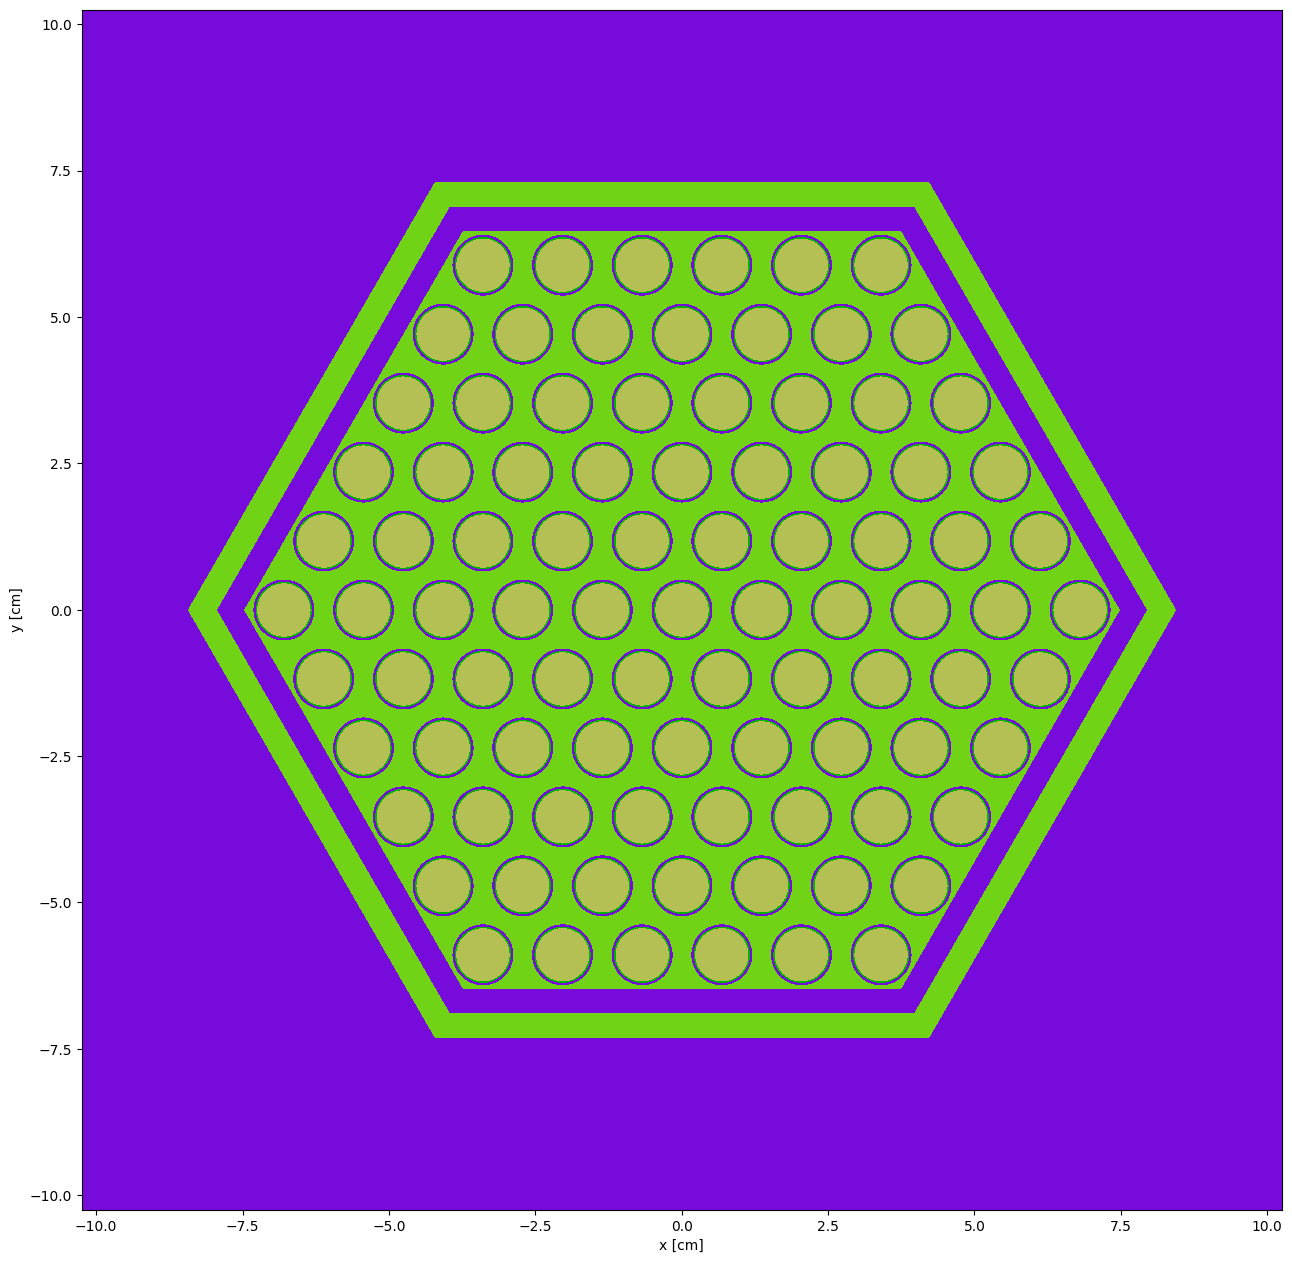

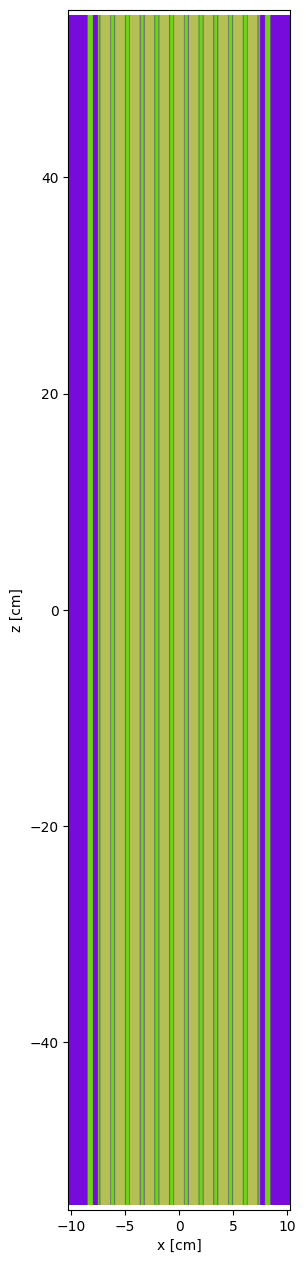

In [30]:
import math


# NEW: pick exactly one assembly universe
asm_uni = uni_main_in_fuel      # or: uni_main_mid_fuel / uni_main_out_fuel / uni_main_blan

# ---- exact width that encloses the OUTERMOST hex (including your +0.5 cm BC ring) ----
# You already defined edge_fuel_ass_out and the BC ring at (edge_fuel_ass_out + 0.5).
edge_bc   = edge_fuel_ass_out + 0.5        # cm  (this is the outermost hex you modeled)  <-- uses your values
D_corners = 4.0 * edge_bc / math.sqrt(3.0) # across-corners diameter of the hex
W_xy      = D_corners + 1.0                # +1 cm safety margin so axes never crop

# Your vertical extent is set by the top/bottom planes at ±55 cm -> height_core = 110 cm.
W_z       = height_core + 1.0              # +1 cm safety margin vertically  <-- uses your value

# ---- XY (top view) – no clipping of the assembly hex ----
asm_uni.plot(origin=(0.0, 0.0, 0.0),
             pixels=(1200, 1200),
             width=(W_xy, W_xy),
             color_by='material')

# ---- XZ (side view through center) – full height, no clipping ----
asm_uni.plot(origin=(0.0, 0.0, 0.0),       # y=0 cuts through the center; avoids “near-flat” slices
             pixels=(1200, 1200),
             width=(W_xy, W_z),
             color_by='material',
             basis='xz')


In [31]:
# Export geometry to xml
geom = openmc.Geometry(uni_main_in_fuel) 
geom.export_to_xml()


## Simulation parameters

In [32]:
import numpy as np

In [33]:
n_pins = 91 #Number of pins in assembly
mat_in_fuel_volume = n_pins *  height_core* diam_fuel_pellet**2 * np.pi
mat_in_fuel.volume = mat_in_fuel_volume
mat_mid_fuel.volume = mat_in_fuel_volume
mat_out_fuel.volume = mat_in_fuel_volume
mat_blan.volume = mat_in_fuel_volume
mat_clad_volume = n_pins * height_core * (out_diam_clad - in_diam_clad)**2 * np.pi + (3*np.sqrt(3)/2 * (edge_fuel_ass_out - edge_fuel_ass_in))
mat_clad.volume = mat_clad_volume
mat_gap_volume = n_pins * height_core * (in_diam_clad - diam_fuel_pellet)**2 * np.pi
mat_gap.volume = mat_gap_volume
mat_cool.volume = (3*np.sqrt(3)/2 * (edge_fuel_ass_out)) - mat_in_fuel_volume - mat_clad_volume - mat_gap_volume

# Instantiate a Materials collection and export to xml
materials_file = openmc.Materials([
    mat_in_fuel, 
    mat_mid_fuel,
    mat_out_fuel,
    mat_clad,
    mat_gap,
    mat_blan,
    mat_cont,
    mat_cool])

materials_file.export_to_xml()


In [34]:
'''
#Creating box approx. containing core
lower_left = [-diam_core/2/10, -diam_core/2, -height_core/2] # to wit: z_height=100
upper_right = [diam_core/2/10, diam_core/2, height_core/2]

print(diam_core/2/10)
print(diam_core/2/10)
#Uniform distribution of coordinates in a rectangular cuboid (should by cylinder...).
uniform_dist = openmc.stats.Box(lower_left, upper_right)

#Initial exernal source distribution
src = openmc.IndependentSource(
    space=uniform_dist, 
    constraints={'fissionable': True}) #limits which sampled source sites are actually used for transport (only fissionable material)
'''
# Convert mm → cm once, then use consistently
core_radius_cm   = (diam_core / 2) / 10.0   # e.g., 300 mm → 15.0 cm
half_height_cm   = height_core / 2.0        # if height_core already in cm

lower_left  = [-core_radius_cm, -core_radius_cm, -half_height_cm]
upper_right = [ core_radius_cm,  core_radius_cm,  half_height_cm]

uniform_dist = openmc.stats.Box(lower_left, upper_right)

src = openmc.IndependentSource(
    space=uniform_dist,
    constraints={'fissionable': True}  # keep this if you like
)


settings = openmc.Settings()
settings.temperature = {'method': 'interpolation'}

settings.source = src

#Run strategy (NB: here only one fission generation per batch  (std. setting))
settings.batches = 500
#Inactive Batches: batches run before tallies are 'turned on'. 
settings.inactive = 200
settings.particles = 500


mat_calc = openmc.VolumeCalculation([mat_in_fuel, mat_clad, mat_gap, mat_blan, mat_cont, mat_cool], 1000000,
                                    lower_left, upper_right)

vol_calc = openmc.VolumeCalculation([cell_in_fuel, cell_in_gap, cell_in_clad, cell_in_cool, cell_blan, cell_gap_blan, cell_clad_blan, cell_cool_blan, cell_in_as_clad,cell_main_lat_in_fuel,cell_clad_lat_in_fuel,cell_out_lat_in_fuel_BC,cell_out_lat_in_fuel], 1000000,
                                    lower_left, upper_right)

settings.volume_calculations = [vol_calc]

settings.export_to_xml()

## Run OpenMC

In [35]:
RUN_variable = True
if RUN_variable:
    openmc.run()


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################